### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 10</center>
---

### Overview

The main objective of this exercise is to study lowpass filters in the frequency domain and their application. For this purpose, three types of lowpass filters are considered: the ideal lowpass filter (ILPF), the Butterworth lowpass filter (BLPF), and the Gaussian lowpass filter (GLPF).

In the frequency domain, the filters are typically constructed so that they are centered at $(M/2, N/2$), if the filter size is $M\times N$ (typically identical to the size of the image to be filtered). The distance to the center can be computed as follows:

$$D(u, v) = \sqrt{(u-M/2)^2 + (v-N/2)^2}$$

The following figure shows the transfer functions of the filters and their shapes:
<br />
<center><img src="images/lowpass-filters.png"  width="800px" /></center>

All transfer functions are real and symmetric (zero-phase-shift filters) so that the IDFT should be real as well. In practice, the IDFT often has very small imaginary parts due to rounding errors and other computational inaccuracies. It is therefore common to work with the real part of the IDFT only.

The centered spatial representation of such filters can be computed in different ways, as exemplarily shown for an ILPF (in this exercise, the first variant is used):
<br />
<center><img src="images/idft-filters.png"  width="600px" /></center>

Filtering in the frequency domain is performed by an elementwise multiplication of the filter transfer function $H(u,v)$ and the centered Fourier transform $F(u,v)$ of the image to be filtered. For this purpose, the Numpy function <a href="https://numpy.org/doc/stable/reference/generated/numpy.multiply.html">`multiply` ↗</a> can be used.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

In [2]:
# based on the log transformation from task sheet 4
def log_transformation(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    for iy in range(rows):
        for jx in range(cols):
            c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
            res[iy, jx] = c * np.log(1 + img[iy, jx]) # min of log = 0, max = np.log(1 + img[i, j])
            
    # return result
    return res

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.1</span> Notch Filter

The notch filter is a basic filter and forces the average value of an image to zero. This can be achieved by setting the Fourier transform $F(u,v)$ of an image $f(x,y)$ to zero at $F(0,0)$ or $F(M/2, N/2)$, depending on whether the Fourier transform has been centered or not. In other words, the Fourier transform at these positions is the mean value of the image. In terms of a transfer function, the notch filter can be expressed as follows:

$$
H(u,v) =
\begin{cases}
0 & \text{if }(u,v) = 0\text{ or }(u,v)=(M/2, N/2) & (4.58)\\
1 & \text{otherwise}
\end{cases}
$$

Implement / solve the following tasks:
    
1. Compute the DFT of the image *p-building-small.png*.
2. Apply the notch filter (set the mean value of the image to zero).
3. Compute the corresponding IDFT and plot the result.

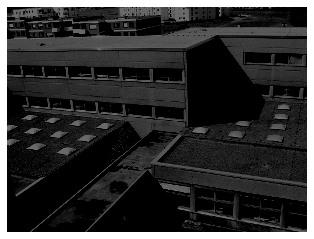

In [10]:
# write your code here

# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/p-building-small.png', 0)

# normal (forward) DFT
img_dft = np.fft.fft2(img) # compute DFT (no normalization to 1/MN)

# set mean value to zero
img_dft[0, 0] = 0

# inverse DFT (IDFT)
img_idft = np.fft.ifft2(img_dft) # compute IDFT
img_back = np.real(img_idft) # take only real part, as all imaginary parts are parasitic

# plot the result (result is clipped)
plot_img_orig(img_back)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.2</span> Ideal Lowpass Filter

Implement / solve the following tasks:
    
1. Write a function to create a $M\times N$ ideal lowpass filter with given cutoff frequency $D_0$.
2. Create $200 \times 200$ lowpass filters with $D_0 = 10, 20, 30$, respectively, and plot them (multiply by $255$ for this).
3. Write a function to multiply a transfer function by $(-1)^{(u+v)}$ or an image by $(-1)^{(x+y)}$.
4. Write a function to compute the centered spatial representation $h(x,y)$ of a given transfer function $H(u,v)$.
5. Compute and plot the (normalized) spatial representations of the filters from the second subtask and compare the results.

In [16]:
# compute transfer function of ideal lowpass filter (ILPF) with cutoff frequency (radius) d0
def tf_ilpf(rows, cols, d0):
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    # compute center coordinates
    cm = int(rows / 2)
    cn = int(cols / 2)
    
    # iterate trough image
    for iu in range(rows):
        for jv in range(cols):
            d = np.sqrt((iu-cm)**2 + (jv-cn)**2) # distance to the center  (from equation (4.61) from lecture slides)
            
            if d <= d0:                                                  #(TF, from equation (4.60) )
                res[iu, jv] = 1

    # return result
    return res

In [17]:
# multiply given image by (-1)^(x+y) 
def center(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros
    
    # iterate trough image
    for ix in range(rows):
        for jy in range(cols):
            res[ix, jy] = img[ix, jy] * (-1)**(ix+jy)

    # return result
    return res

In [18]:
# compute centered spatial representation h(x,y) of a given transfer function H(u,v)
def spatial_repr(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros
    
    #1 multiply H(u,v) by (-1)^(u+v)
    res = center(img)
    
    #2 IDFT and real part
    res = np.fft.ifft2(res)
    res_re = np.real(res)  
    
    #3 multiply h(x,y) by (-1)^(x+y)
    res = center(res_re)
    
    # return result
    return res

In [19]:
# create filters and plot them
ilpf1 = tf_ilpf(200, 200, 10) 
cv2.imwrite("output/ilpf1.png", 255*ilpf1)

ilpf2 = tf_ilpf(200, 200, 20) 
cv2.imwrite("output/ilpf2.png", 255*ilpf2)

ilpf3 = tf_ilpf(200, 200, 30) 
cv2.imwrite("output/ilpf3.png", 255*ilpf3)

True

In [8]:
# compute the centered spatial representations
ilpf1_spatial = spatial_repr(ilpf1)
ilpf2_spatial = spatial_repr(ilpf2)
ilpf3_spatial = spatial_repr(ilpf3)

In [9]:
# normalize and plot the results
ilpf1_spatial_n = cv2.normalize(ilpf1_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/ilpf1_spatial_n.png", ilpf1_spatial_n)

ilpf2_spatial_n = cv2.normalize(ilpf2_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/ilpf2_spatial_n.png", ilpf2_spatial_n)

ilpf3_spatial_n = cv2.normalize(ilpf3_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/ilpf3_spatial_n.png", ilpf3_spatial_n)

True

<table align="left">
<tr>
    <td>$H(u,v)$</td>
    <td>$h(x,y)$</td>
</tr>
<tr>
    <td><img src="output/ilpf1.png"></td>
    <td><img src="output/ilpf1_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/ilpf2.png"></td>
    <td><img src="output/ilpf2_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/ilpf3.png"></td>
    <td><img src="output/ilpf3_spatial_n.png"></td>
</tr>
</table>

In the spatial domain, the filter resembles a sinc function, which is why ringing can later be found in the filtered images. Furthermore, the inverse relationship between the structure size in the spatial and frequency domain becomes apparent. For the extreme case that the lowpass filter is an impulse, the corresponding spatial represenation is a constant (not shown here).

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.3</span> Butterworth Lowpass Filter

Implement / solve the following tasks:
    
1. Write a function to create a $M\times N$ Butterworth lowpass filter with given cutoff frequency $D_0$ and order $n$.
2. Create $200 \times 200$ Butterworth lowpass filters with $D_0 = 10, 20, 30$ and $n=2, 10$, respectively, and plot them (multiply by $255$ for this).
3. Compute and plot the (normalized) spatial representations of the filters from the second subtask and compare the results.

In [20]:
#1 compute transfer function of Butterworth lowpass filter (BLPF) w/ cutoff frequency d0 and order n
def tf_blpf(rows, cols, d0, n):
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    # compute center coordinates
    cm = int(rows / 2)
    cn = int(cols / 2)
    
    # iterate trough image
    for iu in range(rows):
        for jv in range(cols):
            d = np.sqrt((iu-cm)**2 + (jv-cn)**2)      # distance to the center
            res[iu, jv] = 1 / (1 + (d/d0)**(2*n))     #formula for BLPF

    # return result
    return res

In [21]:
#2 create filters and plot them
# n = 2
blpf1 = tf_blpf(200, 200, 10, 2) 
cv2.imwrite("output/blpf1.png", 255*blpf1)

blpf2 = tf_blpf(200, 200, 20, 2) 
cv2.imwrite("output/blpf2.png", 255*blpf2)

blpf3 = tf_blpf(200, 200, 30, 2) 
cv2.imwrite("output/blpf3.png", 255*blpf3)

True

In [22]:
# n = 10
blpf4 = tf_blpf(200, 200, 10, 10) 
cv2.imwrite("output/blpf4.png", 255*blpf4)

blpf5 = tf_blpf(200, 200, 20, 10)
cv2.imwrite("output/blpf5.png", 255*blpf5)

blpf6 = tf_blpf(200, 200, 30, 10)
cv2.imwrite("output/blpf6.png", 255*blpf6)

True

In [23]:
# compute the centered spatial representations 1 to 3
blpf1_spatial = spatial_repr(blpf1)
blpf2_spatial = spatial_repr(blpf2)
blpf3_spatial = spatial_repr(blpf3)

In [24]:
# compute the centered spatial representations 4 to 6
blpf4_spatial = spatial_repr(blpf4)
blpf5_spatial = spatial_repr(blpf5)
blpf6_spatial = spatial_repr(blpf6)

In [25]:
# normalize and plot the results
blpf1_spatial_n = cv2.normalize(blpf1_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf1_spatial_n.png", blpf1_spatial_n)

blpf2_spatial_n = cv2.normalize(blpf2_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf2_spatial_n.png", blpf2_spatial_n)

blpf3_spatial_n = cv2.normalize(blpf3_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf3_spatial_n.png", blpf3_spatial_n)

True

In [26]:
blpf4_spatial_n = cv2.normalize(blpf4_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf4_spatial_n.png", blpf4_spatial_n)

blpf5_spatial_n = cv2.normalize(blpf5_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf5_spatial_n.png", blpf5_spatial_n)

blpf6_spatial_n = cv2.normalize(blpf6_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/blpf6_spatial_n.png", blpf6_spatial_n)

True

<table align="left">
<tr>
    <td>$H(u,v)$</td>
    <td>$h(x,y)$</td>
</tr>
<tr>
    <td><img src="output/blpf1.png"></td>
    <td><img src="output/blpf1_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/blpf2.png"></td>
    <td><img src="output/blpf2_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/blpf3.png"></td>
    <td><img src="output/blpf3_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/blpf4.png"></td>
    <td><img src="output/blpf4_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/blpf5.png"></td>
    <td><img src="output/blpf5_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/blpf6.png"></td>
    <td><img src="output/blpf6_spatial_n.png"></td>
</tr>
</table>

In the frequency domain, the transfer functions are much smoother than the transfer functions of the ILPF. The cutoff frequency is controlled by $D_0$, while the level of smoothness is controlled by the order $n$. The larger the order, the sharper the transition and the more ringing. This can clearly be seen for $n=10$, for which the transfer function already approaches an ILPF. Therefore, $n=2$ is often a good choice in practice.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.4</span> Gaussian Lowpass Filter

Implement / solve the following tasks:
    
1. Write a function to create a $M\times N$ Gaussian lowpass filter with given cutoff frequency $D_0$ ($=\sigma$).
2. Create $200 \times 200$ Gaussian lowpass filters with $D_0 = 10, 20, 30$, respectively, and plot them (multiply by $255$ for this).
3. Compute and plot the (normalized) spatial representations of the filters from the second subtask and compare the results.

In [27]:
# compute transfer function of Butterworth lowpass filter (BLPF) w/ cutoff frequency d0 and order n
def tf_glpf(rows, cols, d0):
    # create empty image
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    # compute center coordinates
    cm = int(rows / 2)
    cn = int(cols / 2)
    
    # iterate trough image
    for iu in range(rows):
        for jv in range(cols):
            d = np.sqrt((iu-cm)**2 + (jv-cn)**2) # distance to the center
            res[iu, jv] = np.exp(-d*d / (2*(d0**2)))

    # return result
    return res

In [28]:
# create filters and plot them
glpf1 = tf_glpf(200, 200, 10)
cv2.imwrite("output/glpf1.png", 255*glpf1)

glpf2 = tf_glpf(200, 200, 20) 
cv2.imwrite("output/glpf2.png", 255*glpf2)

glpf3 = tf_glpf(200, 200, 30) 
cv2.imwrite("output/glpf3.png", 255*glpf3)

True

In [29]:
# compute the centered spatial representations
glpf1_spatial = spatial_repr(glpf1)
glpf2_spatial = spatial_repr(glpf2)
glpf3_spatial = spatial_repr(glpf3)

In [30]:
# normalize and plot the results
glpf1_spatial_n = cv2.normalize(glpf1_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/glpf1_spatial_n.png", glpf1_spatial_n)

glpf2_spatial_n = cv2.normalize(glpf2_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/glpf2_spatial_n.png", glpf2_spatial_n)

glpf3_spatial_n = cv2.normalize(glpf3_spatial, None, 0, 255, cv2.NORM_MINMAX) 
cv2.imwrite("output/glpf3_spatial_n.png", glpf3_spatial_n)

True

<table align="left">
<tr>
    <td>$Frequency: H(u,v)$</td>
    <td>$Spatial: h(x,y)$</td>
</tr>
<tr>
    <td><img src="output/glpf1.png"></td>
    <td><img src="output/glpf1_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/glpf2.png"></td>
    <td><img src="output/glpf2_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/glpf3.png"></td>
    <td><img src="output/glpf3_spatial_n.png"></td>
</tr>
</table>

The transfer functions are again smooth and there is no ringing in the spatial domain. This is because a Gaussian in the frequency domain corresponds to a Gaussian in the spatial domain. This is important in applications where artifacts are not acceptable (e.g., in medical imaging). In comparison to a BLPF of order $n=2$, the spatial representation of the GLPF is smaller for the same value of $D_0$ (compare for $D_0 = 5$). In other words, the smoothing in comparison to a BLPF would be less.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.5</span> Padding and Cropping

Filtering in the frequency domain is performed by an elementwise multiplication of the filter transfer function $H(u,v)$ and the centered Fourier transform $F(u,v)$ of the image to be filtered. In the spatial domain, the multiplication corresponds to a circular convolution (DFT automatically implies periodicity so that the multiplication corresponds to a convolution of periodic functions in the spatial domain, see lecture notes for details). This leads to a wraparound error, which can be avoided by zero padding the input images of the circular convolution. If the images have the same size $M\times N$, then the new size (after padding) can be selected as $2M \times 2N$, where the input image is aligned at the top left.

Implement / solve the following tasks:
    
1. Filter the image *gray.png* in the frequency domain by an ILPF with $D_0 = 10$ without zero padding and plot the result after the IDFT.
2. Write a function to add suitable zero padding to the input image and plot the padded image.
3. Again filter the image *gray.png* and plot the result, but this time with zero padding and $D_0 = 20$. Compare the results.
4. Write a function to crop the padded result to the original image size and plot the result.

In [31]:
# pad image with zeros
def zero_pad_img(img):
    rows, cols = img.shape # get image size
    res = cv2.copyMakeBorder(img, 0, rows, 0, cols, cv2.BORDER_CONSTANT) # top, bottom, left, right
    #padding is done on the bottom and right side of the victim image
    return res

In [32]:
# crop image
def crop_img(img):
    rows, cols = img.shape # get image size

    # compute center coordinates
    cm = int(rows / 2)
    cn = int(cols / 2)
    
    # crop and return image
    res = img[0:cm, 0:cn]
    return res

In [33]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/gray.png', 0)

In [34]:
# DFT
img_dft = np.fft.fft2(img) # compute DFT (no normalization to 1/MN)
img_dft_shift = np.fft.fftshift(img_dft) # shift FFT to the center

In [35]:
# filtering
rows, cols = img.shape
ilpf = tf_glpf(rows, cols, 10) # compute/generate ILPF
img_filtered_uv = np.multiply(img_dft_shift, ilpf)

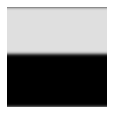

In [36]:
# IDFT and plot
img_filtered_uv_backshift = np.fft.ifftshift(img_filtered_uv) # shift centered FFT back to top left
img_idft = np.fft.ifft2(img_filtered_uv_backshift) # compute IDFT
img_idft_re = np.real(img_idft) # take only real part, as all imaginary parts are parasitic
plot_img_orig(img_idft_re)

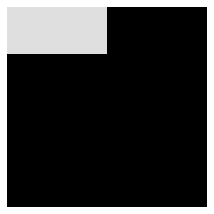

In [37]:
# apply zero padding and plot the result
img_padded = zero_pad_img(img)
plot_img_orig(img_padded)

In [28]:
# DFT
img_padded_dft = np.fft.fft2(img_padded) # compute DFT (no normalization to 1/MN)
img_padded_dft_shift = np.fft.fftshift(img_padded_dft) # shift FFT to the center

In [29]:
# filtering
rows, cols = img_padded.shape
ilpf = tf_glpf(rows, cols, 20) # compute ILPF (note the doubled radius)
img_padded_filtered_uv = np.multiply(img_padded_dft_shift, ilpf)

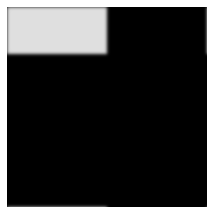

In [30]:
# IDFT and plot (BIRB, backshift, inverse, real(.) backshift)
img_padded_filtered_uv_backshift = np.fft.ifftshift(img_padded_filtered_uv) # shift centered FFT back to top left
img_padded_idft = np.fft.ifft2(img_padded_filtered_uv_backshift) # compute IDFT
img_padded_idft_re = np.real(img_padded_idft) # take only real part, as all imaginary parts are parasitic
plot_img_orig(img_padded_idft_re)

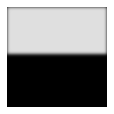

In [31]:
# crop to original size
img_padded_idft_re_crop = crop_img(img_padded_idft_re)
plot_img_orig(img_padded_idft_re_crop)

Filtering the image without zero padding leads to a black border at the bottom, but not at the sides. To get uniform blurring, the input image can be zero padded, filtered (where the filter size has to be increased to the size of the padded image), transformed back, and then cropped. Note that in the frequency domain, the filter has to be padded as well. But if the size of the filter in the frequency domain is doubled, its cutoff frequency has to be doubled as well to get the same amount of blurring. On the other hand, the wraparound error might be acceptable (small) so that these steps can be skipped in some applications.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 10.6</span> Application of Lowpass Filters

Filtering in the frequency domain can be summarized as follows:
1. Compute the DFT $F(u,v)$ of the input image $f(x,y)$.
2. Shift the DFT to the center.
3. Elementwise multiplication of $F(u,v)$ by a filter (transfer) function $H(u,v)$.
4. Backshift the filter result.
5. Compute the IDFT.
6. Obtain the real part of the IDFT, which is the final result.

Padding and cropping can be implemented to avoid wraparound errors. Instead of shifting and backshifting, the functions can be multiplied by $(-1)^{(x+y)}$ before the DFT and $(-1)^{(u+v)}$ before the IDFT.

Implement / solve the following tasks:
    
1. Write a function to filter a given image with a given filter, where the image and filter have the same size.
2. Use the transfer functions for the ILPF, BLPF, and GLPF from the previous tasks to filter some images (e.g., *fruits-small.png*, which has a has a size of $200 \times 200$ pixels) and compare the results.

In [32]:
# filter image with given filter (image and filter must have the same size)
def filter_img(img, tf_filter):
    # DFT of image
    img_dft = np.fft.fft2(img) # compute DFT (no normalization to 1/MN)
    img_dft_shift = np.fft.fftshift(img_dft) # shift FFT to the center
    
    # filter the image
    img_filtered_uv = np.multiply(img_dft_shift, tf_filter)

    # inverse DFT (IDFT)
    img_dft_backshift = np.fft.ifftshift(img_filtered_uv) # shift centered FFT back to top left
    img_idft = np.fft.ifft2(img_dft_backshift) # compute IDFT
    img_back = np.real(img_idft) # take only real part, as all imaginary parts are parasitic
    
    return img_back

In [33]:
# read the image as a grayscale image (parameter 0)
#img = cv2.imread('images/checkerboard.png', 0)
img = cv2.imread('images/fruits-small.png', 0)

ILPF:


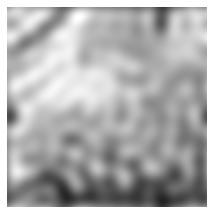

In [34]:
# ILPF
print("ILPF:")
ilpf1_res = filter_img(img, ilpf1)
plot_img_orig(ilpf1_res)

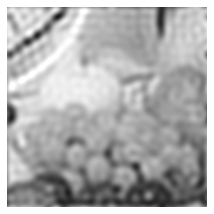

In [35]:
ilpf2_res = filter_img(img, ilpf2)
plot_img_orig(ilpf2_res)

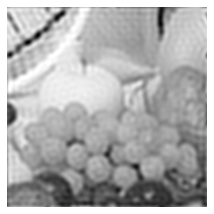

In [36]:
ilpf3_res = filter_img(img, ilpf3)
plot_img_orig(ilpf3_res)

BLPF:


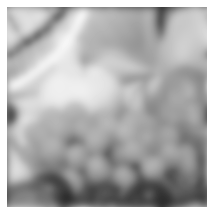

In [37]:
# BLPF
print("BLPF:")
blpf1_res = filter_img(img, blpf1)
plot_img_orig(blpf1_res)

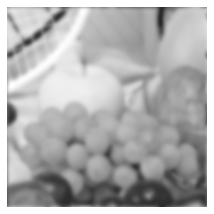

In [38]:
blpf2_res = filter_img(img, blpf2)
plot_img_orig(blpf2_res)

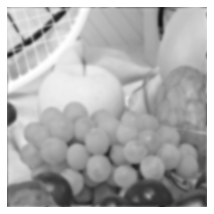

In [39]:
blpf3_res = filter_img(img, blpf3) 
plot_img_orig(blpf3_res)

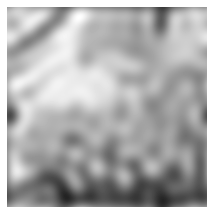

In [40]:
blpf4_res = filter_img(img, blpf4)
plot_img_orig(blpf4_res)

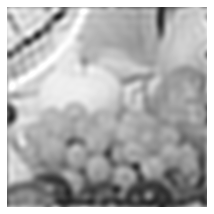

In [41]:
blpf5_res = filter_img(img, blpf5)
plot_img_orig(blpf5_res)

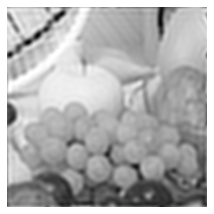

In [42]:
blpf6_res = filter_img(img, blpf6)
plot_img_orig(blpf6_res)

GLPF:


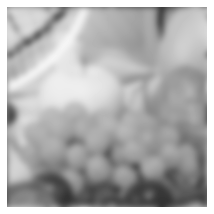

In [43]:
# GLPF
print("GLPF:")
glpf1_res = filter_img(img, glpf1)
plot_img_orig(glpf1_res)

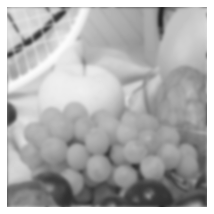

In [44]:
glpf2_res = filter_img(img, glpf2)
plot_img_orig(glpf2_res)

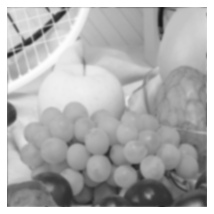

In [45]:
glpf3_res = filter_img(img, glpf3)
plot_img_orig(glpf3_res)